# Decision Transformer: HalfCheetah Offline Policy Training

**Project:** Eliminating the High-Risk Interaction Cost of Autonomous Robotics through Offline Sequence Modeling: A Decision Transformer Approach  
**Authors:** Darwin Juan, Dan Kast, David Terando  
**Date:** April 2026

---

## Notebook Overview

This notebook implements the full Decision Transformer (DT) pipeline on the Minari HalfCheetah datasets validated during EDA. The pipeline has five stages:

| Section | Description |
|---------|-------------|
| **0** | Global Configuration — all tunable hyperparameters in one place |
| **1** | Environment & Dependency Setup |
| **2** | Data Loading & Preprocessing — Minari → RTG-annotated trajectory buffer |
| **3** | Decision Transformer Architecture — GPT-2 backbone from scratch |
| **4** | Training Loop — with HardwareTracker (BPS, wall-clock, GPU/MPS/CPU stats) |
| **5** | Offline Policy Evaluation — MuJoCo rollouts with RTG conditioning |
| **6** | Cross-Platform Hardware Comparison |

**Hardware targets:** M5 Max MacBook Pro (MPS), M1 iMac (MPS), Cloud GPU (CUDA)  
**Dataset:** `mujoco/halfcheetah/medium-v0` + `mujoco/halfcheetah/expert-v0` (Minari Combined)  
**Architecture:** GPT-2 backbone, built from scratch with HuggingFace `transformers`

---

> **Reproducibility note:** All random seeds are set in Section 0. Run cells top-to-bottom for a fully reproducible run.

___
___
## Section 0: Global Configuration

All hyperparameters, file paths, and runtime toggles for this notebook are
defined in a single `Config` dataclass below. **Edit this cell — not the code
in later sections — when tuning or switching hardware.**

This single-source-of-truth design ensures that changes to batch size, context
length, or target RTG automatically propagate to every section that reads from
`CFG`, eliminating the silent inconsistencies that arise when hyperparameters
are hardcoded in individual cells.

### Key design decisions encoded in `CFG`

**Dataset** — two Minari splits are combined to form a medium-expert mixture
that mirrors the D4RL `halfcheetah-medium-expert-v2` benchmark. Combining 1,000
medium episodes with 1,000 expert episodes gives the model exposure to both
competent and optimal behavior, which is the configuration used in the original
DT paper.

**Context window (`context_len = 30`)** — the number of `(RTG, state, action)`
triplets the transformer attends to at each step. The original DT paper uses
`K = 20` for HalfCheetah. This run extends the window to `K = 30`, increasing
the model's backward-looking horizon from 20 to 30 steps. The motivation and
effect on policy behavior are discussed in Section 4.6.

**RTG scale (`rtg_scale = 16585.0`)** — raw RTG values are divided by this
constant before being fed to the model, keeping inputs in the range [0, 1].
This value was determined from EDA as the maximum episode return observed in
the combined Minari dataset.

**Target RTG (`target_rtg = 9000.0`)** — the conditioning target used during
MuJoCo rollouts. Chosen based on the RTG sweep conducted in Run 2 (Section 5.2
sweep analysis), which identified 9,000 as the value that maximizes mean
normalized return while minimizing episode variance.

**Evaluation episodes (`eval_episodes = 50`)** — increased from 20 (used in
earlier runs) to 50 for the reasons detailed in Section 5.2. The larger sample
size provides more reliable mean estimates and better coverage of rare failure
modes.

**Hardware label (`hardware_label = 'M5-Max-Optimized'`)** — a human-readable
identifier written into all CSV and plot outputs. Change this when running on
different platforms so cross-platform comparisons in Section 5.5 remain
unambiguous.


In [1]:
from dataclasses import dataclass, field
from typing import Optional

# ─────────────────────────────────────────────────────────────────────────────
# GLOBAL CONFIGURATION
# All tunable values live here. Sections below read from CFG — never hardcode.
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class Config:

    # ── Reproducibility ───────────────────────────────────────────────────────
    seed: int = 42

    # ── Dataset ───────────────────────────────────────────────────────────────
    minari_medium_id: str  = 'mujoco/halfcheetah/medium-v0'
    minari_expert_id: str  = 'mujoco/halfcheetah/expert-v0'

    # ── MuJoCo environment ────────────────────────────────────────────────────
    # 'HalfCheetah-v4' is the current Gymnasium API (recommended).
    # Switch to 'HalfCheetah-v2' to reproduce the original DT paper exactly.
    mujoco_env_id: str     = 'HalfCheetah-v4'

    # ── State / action dimensions (fixed by HalfCheetah) ─────────────────────
    state_dim: int         = 17
    action_dim: int        = 6
    max_ep_len: int        = 1000   # all HalfCheetah episodes are exactly 1000 steps

    # ── Context window ────────────────────────────────────────────────────────
    # K = number of (RTG, state, action) triplets the transformer sees at once.
    # Original DT paper uses K=20 for HalfCheetah; increase for richer context.
    context_len: int       = 20     # K in the paper

    # ── Transformer architecture ──────────────────────────────────────────────
    # These match the 'small' DT config from the original paper.
    hidden_dim: int        = 128    # embedding / hidden size (n_embd)
    n_layers: int          = 3      # number of transformer blocks
    n_heads: int           = 2      # attention heads
    dropout: float         = 0.1    # residual dropout

    # ── Training ──────────────────────────────────────────────────────────────
    # batch_size: tuned for M5 Max 128 GB unified memory.
    # The full dataset is ~176 MB; even a batch of 512 × K=20 windows
    # occupies < 10 MB on-device, so memory is not the bottleneck here.
    # 256 saturates MPS throughput well; increase to 512 if BPS plateaus.
    batch_size: int        = 64
    learning_rate: float   = 1e-4
    weight_decay: float    = 1e-4
    warmup_steps: int      = 10_000
    cosine_eta_min : float = 0.0        # LR floor at end of cosine decay
    grad_clip: float       = 0.25   # max gradient norm

    # Quick-validation run: a small number of iterations to verify the pipeline
    # works end-to-end before committing to the full run.
    quick_val_iters: int   = 500    # ~minutes on M5 Max

    # Full training run: matches the DT paper's 100k gradient steps.
    full_train_iters: int  = 100_000

    # Set to True to run quick validation first, then ask before full run.
    run_quick_val_first: bool = True

    # ── RTG normalization ─────────────────────────────────────────────────────
    # Scale factor applied to raw RTG values before feeding to the model.
    # Keeps RTG inputs in a numerically stable range (~0-1).
    # Set to max episode return observed in the combined Minari dataset (EDA §10).
    rtg_scale: float       = 16_585.0

    # Target RTG used during MuJoCo inference rollouts (also from EDA §10).
    target_rtg: float      = 16_585.0

    # ── Evaluation ────────────────────────────────────────────────────────────
    eval_episodes: int     = 50     # number of MuJoCo rollout episodes per eval
    eval_every_n_iters: int = 5_000 # run eval this often during full training

    # ── Checkpointing & outputs ───────────────────────────────────────────────
    checkpoint_dir: str    = './checkpoints'
    results_dir: str       = './results'
    save_every_n_iters: int = 10_000  # save checkpoint this often

    # ── Hardware ──────────────────────────────────────────────────────────────
    # Leave as None to auto-detect (cuda > mps > cpu).
    # Override with 'cuda', 'mps', or 'cpu' to force a specific backend.
    force_device: Optional[str] = None

    # Human-readable label for the hardware tracker logs (used in CSVs / plots).
    # Change this when running on different machines for comparison.
    hardware_label: str    = 'M5-Max-GPT-Cos-wpez-bs64-K20-RTG16585-nh2'  # e.g. 'M1-iMac', 'Lambda-A100'

    # ── Memory strategy ───────────────────────────────────────────────────────
    # With 128 GB unified memory on the M5 Max, the entire preprocessed dataset
    # (~176 MB for 2M timesteps) is pinned in RAM as pre-built PyTorch tensors.
    # This eliminates per-batch numpy slicing and tensor allocation overhead,
    # and is the primary reason BPS is substantially higher on this machine
    # than on memory-constrained platforms.
    #
    # Set to False on machines with < 8 GB RAM to fall back to the standard
    # on-the-fly episode sampling path (slower but memory-safe).
    preload_to_ram: bool   = True


# Instantiate the global config object used throughout the notebook
CFG = Config()

print("=" * 60)
print("  Decision Transformer — Global Configuration")
print("=" * 60)
for k, v in CFG.__dict__.items():
    print(f"  {k:<26} = {v}")
print("=" * 60)


  Decision Transformer — Global Configuration
  seed                       = 42
  minari_medium_id           = mujoco/halfcheetah/medium-v0
  minari_expert_id           = mujoco/halfcheetah/expert-v0
  mujoco_env_id              = HalfCheetah-v4
  state_dim                  = 17
  action_dim                 = 6
  max_ep_len                 = 1000
  context_len                = 20
  hidden_dim                 = 128
  n_layers                   = 3
  n_heads                    = 2
  dropout                    = 0.1
  batch_size                 = 64
  learning_rate              = 0.0001
  weight_decay               = 0.0001
  warmup_steps               = 10000
  cosine_eta_min             = 0.0
  grad_clip                  = 0.25
  quick_val_iters            = 500
  full_train_iters           = 100000
  run_quick_val_first        = True
  rtg_scale                  = 16585.0
  target_rtg                 = 16585.0
  eval_episodes              = 50
  eval_every_n_iters         = 5000
  chec

___
---
## Section 1: Environment Setup & Imports

### 1.1 Dependency Installation

This project uses **uv** for package management. Run the cell below once per environment to install all required packages.

**Expected install command (run in terminal, not here):**
```bash
uv pip install torch torchvision \
    transformers \
    minari[hf] \
    gymnasium[mujoco] \
    mujoco \
    numpy pandas matplotlib seaborn tqdm psutil
```

> **Apple Silicon note (M5 Max / M1 iMac):** PyTorch ships with native MPS support for arm64. No separate CUDA toolkit needed. Install with `uv pip install torch` — the arm64 wheel includes MPS automatically.  
> **Cloud GPU (CUDA):** Install with `uv pip install torch --index-url https://download.pytorch.org/whl/cu121`

### 1.2 Known Issues from EDA (pre-resolved)
- `minari` requires `[hf]` extras: `uv pip install "minari[hf]"`
- Minari dataset IDs use namespaced format: `mujoco/halfcheetah/medium-v0` (not `halfcheetah-medium-v0`)
- `pandas >= 3.x`: use `.map()` not `.applymap()` — already handled below
- `d4rl` package is NOT used — all data comes from Minari

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1: Imports, Seed, and Device Detection
# ─────────────────────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

import os
import sys
import time
import json
import random
import platform
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm
import psutil

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import GPT2Config, GPT2Model

import minari
import gymnasium as gym

# ── Output directories ────────────────────────────────────────────────────────
Path(CFG.checkpoint_dir).mkdir(parents=True, exist_ok=True)
Path(CFG.results_dir).mkdir(parents=True, exist_ok=True)

# ── Global random seed ────────────────────────────────────────────────────────
# Setting seeds in all relevant libraries ensures reproducibility across runs.
random.seed(CFG.seed)
np.random.seed(CFG.seed)
torch.manual_seed(CFG.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CFG.seed)

# ── Device selection ──────────────────────────────────────────────────────────
# Priority: user override > CUDA (NVIDIA GPU) > MPS (Apple Silicon) > CPU
if CFG.force_device:
    DEVICE = torch.device(CFG.force_device)
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

# ── Environment summary ───────────────────────────────────────────────────────
print("=" * 60)
print("  Environment Summary")
print("=" * 60)
print(f"  Python          : {sys.version.split()[0]}")
print(f"  PyTorch         : {torch.__version__}")
print(f"  Device selected : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"  GPU             : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
elif DEVICE.type == 'mps':
    print(f"  Backend         : Apple Metal Performance Shaders (MPS)")
print(f"  Platform        : {platform.processor()} | {platform.machine()}")
print(f"  System RAM      : {psutil.virtual_memory().total / 1e9:.1f} GB")
print(f"  Hardware label  : {CFG.hardware_label}")
print("=" * 60)

  Environment Summary
  Python          : 3.11.15
  PyTorch         : 2.11.0
  Device selected : mps
  Backend         : Apple Metal Performance Shaders (MPS)
  Platform        : arm | arm64
  System RAM      : 137.4 GB
  Hardware label  : M5-Max-GPT-Cos-wpez-bs64-K20-RTG16585-nh2


---
___
## Section 2: Data Loading & Preprocessing

### Pipeline Overview

```
Minari medium-v0  ┐
                  ├─► Combined Episodes ─► RTG Annotation ─► State Normalization ─► SequenceDataset
Minari expert-v0  ┘
```


Three preprocessing steps are required before data can be fed to the Decision
Transformer. Each step is critical and is addressed in its own subsection:

1. **RTG Annotation (2.2)** — for each timestep `t`, compute
   `RTG[t] = Σ rewards[t:end]`. This reverse cumulative sum is the
   conditioning signal the DT receives during training. It tells the model
   "how much total reward remains from this point onward," which is the
   quantity the model learns to condition its actions on.

2. **State Normalization (2.3)** — subtract the global mean and divide by the
   global std, computed across all 2,000,000 timesteps in the combined dataset.
   This step is explicitly identified in the original DT paper as essential for
   training stability. Without it, high-variance state dimensions (e.g.,
   root-velocity components in HalfCheetah) dominate the embedding space and
   cause early training to diverge.

3. **Context-Window Slicing (2.4)** — each training sample is a fixed-length
   window of `K = xx` `(RTG, state, action)` triplets drawn from a random
   position in a random episode. Short windows (near the episode start) are
   zero-padded on the left, and an attention mask ensures the transformer
   ignores padding tokens during the forward pass.


___
### 2.1: Load Minari Datasets

Both Minari splits are loaded and parsed into a flat list of episode
dictionaries. On the first call, Minari downloads the datasets from Hugging
Face Hub and caches them locally; subsequent runs read from the local cache
with no network access required.

**Observation alignment note:** Minari stores `T + 1` observations per episode, the initial observation plus one observation per step. The final observation
is dropped here to align dimensions with the `actions` and `rewards` arrays
(both of length `T`). This is a known Minari convention difference from D4RL.

**Expected output:**
- `mujoco/halfcheetah/medium-v0`: 1,000 episodes, 1,000,000 timesteps
- `mujoco/halfcheetah/expert-v0`: 1,000 episodes, 1,000,000 timesteps
- Combined: 2,000 episodes, 2,000,000 total timesteps


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2.1: Load Minari Datasets
# Downloads on first call (requires internet); uses local cache on subsequent runs.
# ─────────────────────────────────────────────────────────────────────────────

def load_minari_to_episodes(dataset_id: str) -> List[Dict]:
    """
    Load a Minari dataset and return a list of episode dicts.

    Each episode dict has keys:
        observations : np.ndarray (T, state_dim)
        actions      : np.ndarray (T, action_dim)
        rewards      : np.ndarray (T,)
        terminals    : np.ndarray (T,)  — True on the last step of an episode

    Minari stores T+1 observations per episode (initial obs + one per step).
    We drop the final observation to align dimensions with actions/rewards.
    """
    print(f"  Loading: {dataset_id}")
    try:
        ds = minari.load_dataset(dataset_id)
    except Exception:
        print(f"    Not cached — downloading from Hugging Face...")
        minari.download_dataset(dataset_id)
        ds = minari.load_dataset(dataset_id)

    episodes = []
    for ep in tqdm(ds.iterate_episodes(),
                   total=ds.total_episodes,
                   desc=f"    Parsing {dataset_id.split('/')[-1]}",
                   leave=False):
        episodes.append({
            'observations': ep.observations[:-1].astype(np.float32),  # drop terminal obs
            'actions'     : ep.actions.astype(np.float32),
            'rewards'     : ep.rewards.astype(np.float32),
            'terminals'   : ep.terminations.astype(bool),
        })
    print(f"    Loaded {len(episodes):,} episodes, "
          f"{sum(len(e['rewards']) for e in episodes):,} timesteps")
    return episodes


print("Loading Minari datasets...")
episodes_medium = load_minari_to_episodes(CFG.minari_medium_id)
episodes_expert = load_minari_to_episodes(CFG.minari_expert_id)

# Combine into a single flat list of episodes (mirrors D4RL medium-expert structure)
all_episodes = episodes_medium + episodes_expert
print(f"\n  Combined: {len(all_episodes):,} episodes, "
      f"{sum(len(e['rewards']) for e in all_episodes):,} total timesteps")

Loading Minari datasets...
  Loading: mujoco/halfcheetah/medium-v0


    Loaded 1,000 episodes, 1,000,000 timesteps
  Loading: mujoco/halfcheetah/expert-v0


    Loaded 1,000 episodes, 1,000,000 timesteps

  Combined: 2,000 episodes, 2,000,000 total timesteps


___
### 2.2: RTG Annotation

The return-to-go at timestep `t` is defined as the sum of all future rewards
within the episode:

RTG[t] = r[t] + r[t+1] + … + r[T-1]

This is computed efficiently as a reverse cumulative sum and stored alongside
each episode's observations and actions. The sanity check below verifies two
properties: (1) `RTG[0]` equals the total episode return, and (2) the RTG
sequence is monotonically non-increasing — since each step consumes a reward,
the remaining return can only stay flat or decrease.

Note: the "monotone decreasing" check may return `False` for some HalfCheetah
episodes because the environment occasionally produces small negative rewards
(e.g., from the control cost penalty), which can cause local RTG *increases*.
This is expected behavior and does not indicate a bug.


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2.2: RTG Annotation
#
# RTG[t] = Σ rewards[t : end_of_episode]
# This is computed once per episode and stored alongside observations/actions.
#
# Why: the Decision Transformer is conditioned on RTG at every step. During
# training, it sees the ground-truth RTG from the dataset. During inference,
# we set RTG to our target (e.g. 16,585) and decrement by the observed reward.
# ─────────────────────────────────────────────────────────────────────────────

def annotate_rtg(episodes: List[Dict]) -> List[Dict]:
    """Add an 'rtg' key to each episode dict (reverse cumulative sum of rewards)."""
    for ep in episodes:
        # np.cumsum on reversed array, then reverse back = reverse cumsum
        ep['rtg'] = np.cumsum(ep['rewards'][::-1])[::-1].astype(np.float32)
    return episodes

all_episodes = annotate_rtg(all_episodes)

# Sanity check: RTG[0] == total episode return
sample_ep = all_episodes[0]
print(f"RTG annotation check (episode 0):")
print(f"  RTG[0]                : {sample_ep['rtg'][0]:.2f}")
print(f"  sum(rewards)          : {sample_ep['rewards'].sum():.2f}  (should match)")
print(f"  RTG is monotone dec.  : {bool(np.all(np.diff(sample_ep['rtg']) <= 0))}")

RTG annotation check (episode 0):
  RTG[0]                : 13960.90
  sum(rewards)          : 13960.90  (should match)
  RTG is monotone dec.  : False


___
### 2.3: State Normalization

Global normalization statistics are computed by concatenating all 2,000,000
observations from the combined dataset into a single array and computing the
per-dimension mean and standard deviation. Each episode's observations are then
normalized in-place:

obs_normalized[t] = (obs[t] - STATE_MEAN) / STATE_STD


A small `ε = 1e-6` floor is applied to `STATE_STD` to prevent division by
zero in any constant or near-constant state dimension.

The normalized statistics are saved to `./results/state_mean.npy` and
`./results/state_std.npy`. These files are loaded again in Section 5.1 to
apply the same normalization to observations received from the MuJoCo
environment during rollout — a step that is easy to forget and causes silent
performance degradation if omitted.

**Post-normalization check:** the global mean across all normalized observations
should be near zero (within floating-point rounding) and the global std should
be near 1.0 for every state dimension, confirming the normalization was applied
correctly.


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2.3: State Normalization
#
# Compute mean and std across the ENTIRE combined dataset (both splits).
# Normalize every episode's observations in-place.
#
# Why this matters: without normalization, high-variance dimensions (e.g.
# root_x velocity, which can be large) dominate the embedding space and
# destabilize early training. The DT paper reports this as critical.
# ─────────────────────────────────────────────────────────────────────────────

# Stack all observations from the combined dataset to compute global statistics
all_obs = np.concatenate([ep['observations'] for ep in all_episodes], axis=0)
STATE_MEAN = all_obs.mean(axis=0).astype(np.float32)  # shape: (state_dim,)
STATE_STD  = all_obs.std(axis=0).astype(np.float32)   # shape: (state_dim,)

# Guard against zero-std dimensions (avoid division by zero)
STATE_STD = np.maximum(STATE_STD, 1e-6)

# Apply normalization to each episode in-place
for ep in all_episodes:
    ep['observations'] = (ep['observations'] - STATE_MEAN) / STATE_STD

# Save normalization stats — we need them during MuJoCo inference
np.save(f"{CFG.results_dir}/state_mean.npy", STATE_MEAN)
np.save(f"{CFG.results_dir}/state_std.npy",  STATE_STD)

print(f"State normalization computed on {len(all_obs):,} timesteps.")
print(f"  state_mean saved to: {CFG.results_dir}/state_mean.npy")
print(f"  state_std  saved to: {CFG.results_dir}/state_std.npy")
print(f"\nPost-normalization check (should be ~0 mean, ~1 std):")
all_obs_norm = np.concatenate([ep['observations'] for ep in all_episodes], axis=0)
print(f"  Global mean range : [{all_obs_norm.mean(axis=0).min():.4f}, {all_obs_norm.mean(axis=0).max():.4f}]")
print(f"  Global std  range : [{all_obs_norm.std(axis=0).min():.4f}, {all_obs_norm.std(axis=0).max():.4f}]")
del all_obs, all_obs_norm  # free memory — 2M x 17 float32 ≈ 136 MB

State normalization computed on 2,000,000 timesteps.
  state_mean saved to: ./results/state_mean.npy
  state_std  saved to: ./results/state_std.npy

Post-normalization check (should be ~0 mean, ~1 std):
  Global mean range : [-0.0000, 0.0072]
  Global std  range : [0.9985, 1.0004]


___
### 2.4: SequenceDataset — Context-Window Slicing

The `SequenceDataset` class wraps the preprocessed episode buffer and exposes
a PyTorch `Dataset` interface. Each call to `__getitem__` returns a random
`K`-length window of `(RTG, state, action)` triplets sampled uniformly from
all positions in all episodes, weighted proportionally to episode length so
that longer episodes are not underrepresented.

#### M5 Max preload path (`CFG.preload_to_ram = True`)

With 128 GB of unified memory, the entire 2,000,000-timestep dataset is
materialized as contiguous PyTorch tensors in RAM at initialization time
(~208 MB total). Each `__getitem__` call then performs pure tensor indexing
with no numpy allocation or data copy per batch — eliminating the main CPU
bottleneck that limits throughput on memory-constrained machines.

#### Standard path (`CFG.preload_to_ram = False`)

Episode-by-episode numpy slicing on every `__getitem__` call. Slower, but safe
on machines with limited RAM (e.g., an M1 iMac with 16 GB). Both paths produce
bit-identical output tensors.

#### DataLoader configuration

`num_workers = 0` is required on MPS: worker sub-processes cannot share an MPS
device context with the main process, and spawning them causes silent tensor
placement errors on Apple Silicon. `pin_memory` is set only when the device is
CUDA, where it enables PCIe DMA transfers; it has no effect on MPS and is
disabled automatically.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2.4: SequenceDataset — Context-Window Slicing
#
# The DT is trained on fixed-length windows (K triplets) sampled uniformly
# from all positions in all episodes.
#
# M5 Max / 128 GB memory path (CFG.preload_to_ram = True):
#   The entire dataset is materialized as a single pre-stacked PyTorch tensor
#   in RAM at init time. __getitem__ then performs pure tensor indexing with
#   no numpy allocation per call — eliminating the main CPU bottleneck on
#   memory-rich machines. With 2M timesteps at float32 this costs ~176 MB.
#
# Standard path (CFG.preload_to_ram = False):
#   Episode-by-episode numpy slicing on every __getitem__ call. Slower but
#   safe on machines with limited RAM (e.g. M1 iMac with 16 GB).
#
# Both paths produce identical output tensors.
# ─────────────────────────────────────────────────────────────────────────────

class SequenceDataset(Dataset):
    """
    PyTorch Dataset that yields random K-length windows from the offline buffer.

    Each item is a dict of tensors with shape (K, dim):
        states      : (K, state_dim)    normalized observations
        actions     : (K, action_dim)
        rtg         : (K, 1)            scaled RTG values
        timesteps   : (K,)              absolute timestep index within episode
        mask        : (K,)              1 = real data, 0 = left-padding
    """

    def __init__(
        self,
        episodes    : List[Dict],
        context_len : int,
        rtg_scale   : float,
        preload     : bool = True,
    ):
        self.context_len = context_len
        self.rtg_scale   = rtg_scale
        self.preload     = preload

        # Build sampling weights proportional to episode length.
        lengths = np.array([len(ep['rewards']) for ep in episodes], dtype=np.int64)
        self.sample_weights  = (lengths / lengths.sum()).astype(np.float64)
        self.total_timesteps = int(lengths.sum())

        # ── Episode boundary index ─────────────────────────────────────────
        # For fast episode lookup: given a global timestep, which episode
        # does it belong to and at what local offset?
        # cumulative_ends[i] = index of the last timestep in episode i (exclusive)
        self.episode_lengths = lengths
        self.ep_starts = np.concatenate([[0], np.cumsum(lengths[:-1])])

        if preload:
            self._preload_to_ram(episodes)
        else:
            # Standard path: keep episodes as list of numpy arrays
            self.episodes = episodes

    def _preload_to_ram(self, episodes: List[Dict]):
        """
        Concatenate all episode data into contiguous PyTorch tensors.

        Memory layout (float32):
          states  : (total_T, state_dim)   ~  2M × 17 = ~136 MB
          actions : (total_T, action_dim)  ~  2M ×  6 =  ~48 MB
          rtg     : (total_T,)             ~  2M ×  1 =   ~8 MB
          tsteps  : (total_T,)             int32, ~8 MB
        Total: ~200 MB — trivial on 128 GB unified memory.
        """
        import sys
        print("  Pre-loading dataset into RAM (M5 Max / 128 GB path)...")

        states_list  = [ep['observations'] for ep in episodes]
        actions_list = [ep['actions']      for ep in episodes]
        rtg_list     = [ep['rtg']          for ep in episodes]
        tstep_list   = [np.arange(len(ep['rewards']), dtype=np.int32) for ep in episodes]

        # Single concatenation — much faster than incremental appends
        all_states  = np.concatenate(states_list,  axis=0)
        all_actions = np.concatenate(actions_list, axis=0)
        all_rtg     = np.concatenate(rtg_list,     axis=0)
        all_tsteps  = np.concatenate(tstep_list,   axis=0)

        # Store as PyTorch tensors — __getitem__ does pure tensor slicing
        self.t_states  = torch.from_numpy(all_states)                   # float32
        self.t_actions = torch.from_numpy(all_actions)                  # float32
        self.t_rtg     = torch.from_numpy(all_rtg / self.rtg_scale)     # float32, scaled
        self.t_tsteps  = torch.from_numpy(all_tsteps.astype(np.int64))  # int64 for embedding

        mem_mb = (self.t_states.nbytes + self.t_actions.nbytes +
                  self.t_rtg.nbytes + self.t_tsteps.nbytes) / 1e6
        print(f"  Dataset pinned in RAM: {mem_mb:.1f} MB")
        print(f"  RAM available after preload: "
              f"{(psutil.virtual_memory().available / 1e9):.1f} GB")

    def __len__(self):
        # Report total timesteps so one "epoch" nominally covers all data.
        return self.total_timesteps

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        # ── Step 1: Sample an episode (length-proportional) ────────────────
        ep_idx     = np.random.choice(len(self.episode_lengths), p=self.sample_weights)
        ep_len     = int(self.episode_lengths[ep_idx])
        ep_start   = int(self.ep_starts[ep_idx])

        # ── Step 2: Sample a random end-point within the episode ───────────
        t_local    = np.random.randint(0, ep_len)   # local offset within episode
        t_end_g    = ep_start + t_local             # global index in flat tensor
        t_start_l  = max(0, t_local - self.context_len + 1)
        t_start_g  = ep_start + t_start_l
        window_len = t_local - t_start_l + 1       # actual window length (<= K)
        pad        = self.context_len - window_len

        if self.preload:
            # ── Fast path: pure tensor slicing, zero copy ──────────────────
            sl = slice(t_start_g, t_end_g + 1)

            states_w  = self.t_states[sl]   # (window_len, state_dim)
            actions_w = self.t_actions[sl]  # (window_len, action_dim)
            rtg_w     = self.t_rtg[sl]      # (window_len,)
            tsteps_w  = self.t_tsteps[sl]   # (window_len,)

            if pad > 0:
                # Prepend zero padding using torch.cat (stays on CPU, no numpy)
                z_s = torch.zeros(pad, CFG.state_dim,  dtype=torch.float32)
                z_a = torch.zeros(pad, CFG.action_dim, dtype=torch.float32)
                z_r = torch.zeros(pad,                 dtype=torch.float32)
                z_t = torch.zeros(pad,                 dtype=torch.long)
                states_w  = torch.cat([z_s, states_w],  dim=0)
                actions_w = torch.cat([z_a, actions_w], dim=0)
                rtg_w     = torch.cat([z_r, rtg_w],     dim=0)
                tsteps_w  = torch.cat([z_t, tsteps_w],  dim=0)

            mask = torch.zeros(self.context_len, dtype=torch.float32)
            mask[pad:] = 1.0

            return {
                'states'   : states_w,
                'actions'  : actions_w,
                'rtg'      : rtg_w.unsqueeze(-1),   # (K, 1)
                'timesteps': tsteps_w,
                'mask'     : mask,
            }

        else:
            # ── Standard path: numpy slicing (memory-safe fallback) ────────
            ep = self.episodes[ep_idx]
            states  = ep['observations'][t_start_l : t_local + 1].copy()
            actions = ep['actions'][t_start_l      : t_local + 1].copy()
            rtg     = ep['rtg'][t_start_l          : t_local + 1] / self.rtg_scale
            tsteps  = np.arange(t_start_l, t_local + 1, dtype=np.int64)

            if pad > 0:
                states  = np.concatenate([np.zeros((pad, states.shape[1]),  np.float32), states])
                actions = np.concatenate([np.zeros((pad, actions.shape[1]), np.float32), actions])
                rtg     = np.concatenate([np.zeros(pad, np.float32), rtg])
                tsteps  = np.concatenate([np.zeros(pad, np.int64),   tsteps])

            mask = np.zeros(self.context_len, np.float32)
            mask[pad:] = 1.0

            return {
                'states'   : torch.tensor(states,         dtype=torch.float32),
                'actions'  : torch.tensor(actions,        dtype=torch.float32),
                'rtg'      : torch.tensor(rtg[:, None],   dtype=torch.float32),
                'timesteps': torch.tensor(tsteps,         dtype=torch.long),
                'mask'     : torch.tensor(mask,           dtype=torch.float32),
            }


# ── Instantiate dataset and dataloader ───────────────────────────────────────
dataset = SequenceDataset(
    episodes    = all_episodes,
    context_len = CFG.context_len,
    rtg_scale   = CFG.rtg_scale,
    preload     = CFG.preload_to_ram,
)

# DataLoader tuning for M5 Max:
#   num_workers=0  — MPS requires all tensor ops on the main process;
#                    worker processes cannot share MPS context.
#   pin_memory     — only beneficial for CUDA (PCIe DMA); no effect on MPS.
#   persistent_workers — irrelevant at num_workers=0.
#
# With the preloaded tensor buffer, the DataLoader's main bottleneck shifts
# from disk/numpy I/O to the MPS kernel dispatch latency, which is amortized
# by the larger batch size (256 vs 64).
dataloader = DataLoader(
    dataset,
    batch_size = CFG.batch_size,
    shuffle    = True,
    num_workers= 0,
    pin_memory = (DEVICE.type == 'cuda'),
    drop_last  = True,
)

# ── Dataset and memory summary ────────────────────────────────────────────────
ram_total = psutil.virtual_memory().total / 1e9
ram_used  = psutil.virtual_memory().used  / 1e9
print(f"SequenceDataset ready.")
print(f"  Preload mode      : {CFG.preload_to_ram} ({'fast tensor path' if CFG.preload_to_ram else 'standard numpy path'})")
print(f"  Total timesteps   : {dataset.total_timesteps:,}")
print(f"  Context window K  : {CFG.context_len}")
print(f"  Batch size        : {CFG.batch_size}")
print(f"  Steps per epoch   : ~{len(dataset) // CFG.batch_size:,}")
print(f"  RAM used / total  : {ram_used:.1f} GB / {ram_total:.1f} GB")

# Inspect one sample batch
sample_batch = next(iter(dataloader))
print(f"\nSample batch tensor shapes:")
for k, v in sample_batch.items():
    print(f"  {k:<12}: {tuple(v.shape)}")


  Pre-loading dataset into RAM (M5 Max / 128 GB path)...
  Dataset pinned in RAM: 208.0 MB
  RAM available after preload: 28.6 GB
SequenceDataset ready.
  Preload mode      : True (fast tensor path)
  Total timesteps   : 2,000,000
  Context window K  : 20
  Batch size        : 64
  Steps per epoch   : ~31,250
  RAM used / total  : 35.1 GB / 137.4 GB

Sample batch tensor shapes:
  states      : (64, 20, 17)
  actions     : (64, 20, 6)
  rtg         : (64, 20, 1)
  timesteps   : (64, 20)
  mask        : (64, 20)


---
___
## Section 3: Decision Transformer Architecture

### Design

The architecture follows Chen et al. (2021) — *Decision Transformer: Reinforcement
Learning via Sequence Modeling* — exactly, with one modification to the context
window length (K = 30 vs. K = 20 in the paper).

```
Input sequence:  [R̂₁, s₁, a₁,  R̂₂, s₂, a₂,  ...,  R̂ₖ, sₖ, aₖ]
                                                          ↑
                                              Predict this action
                                    


Each triplet `(R̂ₜ, sₜ, aₜ)` is projected to `hidden_dim = 128` via three
separate learned linear maps — one per modality. Timestep embeddings (a learned
lookup table indexed by absolute step number within the episode) are added to
each projected token. The full `3K`-token interleaved sequence is then processed
by a causal GPT-2 transformer. The output at each state-token position is
decoded to a continuous action via a linear head followed by `Tanh` (to bound
actions to the `[-1, 1]` range that HalfCheetah expects).

**Key difference from language modeling:** three independent linear projectors
replace the shared token embedding table. All three projected embeddings share
the same hidden dimension, so the interleaved sequence has uniform token
dimensionality throughout the transformer.

### Architecture summary

| Component | Config |
|---|---|
| State dim | 17 |
| Action dim | 6 |
| Hidden dim (`n_embd`) | 128 |
| Transformer blocks (`n_layers`) | 3 |
| Attention heads (`n_heads`) | 1 |
| Context window (`K`) | 30 |
| Sequence length | 3K = 90 tokens |
| Dropout | 0.1 |
| Total parameters | 739,206 |
| Model size (float32) | ~3.0 MB |


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3: Decision Transformer Model
# ─────────────────────────────────────────────────────────────────────────────

class DecisionTransformer(nn.Module):
    """
    Decision Transformer for continuous control (HalfCheetah).

    Architecture:
      - Three linear 'embedders': RTG (1 → H), state (S → H), action (A → H)
      - Timestep embedding lookup: scalar index → H
      - GPT-2 transformer backbone (causal masking, n_layers, n_heads)
      - Action prediction head: H → A, followed by Tanh to bound [-1, 1]

    Forward input:  (B, K, ·) tensors for rtg, states, actions, timesteps
    Forward output: (B, K, action_dim) predicted actions

    During training:  compare output[:, :, :] to target actions (MSE)
    During inference: use only output[:, -1, :] — the last-step prediction
    """

    def __init__(
        self,
        state_dim  : int,
        action_dim : int,
        hidden_dim : int,
        context_len: int,
        n_layers   : int,
        n_heads    : int,
        dropout    : float,
        max_ep_len : int,
    ):
        super().__init__()

        self.state_dim   = state_dim
        self.action_dim  = action_dim
        self.hidden_dim  = hidden_dim
        self.context_len = context_len

        # ── 1. Linear projectors ───────────────────────────────────────────
        # Each of the three modalities is projected to the same hidden_dim.
        # No activation — just a learned linear map.
        self.embed_rtg    = nn.Linear(1,          hidden_dim)
        self.embed_state  = nn.Linear(state_dim,  hidden_dim)
        self.embed_action = nn.Linear(action_dim, hidden_dim)

        # ── 2. Timestep embedding ──────────────────────────────────────────
        # Maps each absolute timestep index (0 to max_ep_len-1) to a vector.
        # This replaces the positional encoding in language models — it tells
        # the model 'where in the episode' each triplet was observed.
        self.embed_timestep = nn.Embedding(max_ep_len, hidden_dim)

        # Shared layer norm applied after all three embeddings are added
        self.embed_ln = nn.LayerNorm(hidden_dim)

        # ── 3. GPT-2 transformer backbone ──────────────────────────────────
        # We use HuggingFace's GPT2Config to construct a causal transformer
        # with our custom dimensions. The causal mask is handled internally.
        gpt2_config = GPT2Config(
            n_embd       = hidden_dim,
            n_layer      = n_layers,
            n_head       = n_heads,
            n_inner      = 4 * hidden_dim,   # feedforward dimension
            activation_function = 'relu',
            n_positions  = 3 * context_len,  # sequence is 3K tokens (RTG, s, a)
            n_ctx        = 3 * context_len,
            resid_pdrop  = dropout,
            attn_pdrop   = dropout,
            vocab_size   = 1,                # unused — we don't use token embeddings
        )
        self.transformer = GPT2Model(gpt2_config)

# ── wpe ablation: zero out GPT-2's learned positional embedding and freeze it ──
# This isolates the hypothesis that the wpe table interferes with RTG conditioning
# learning. If the eval score rises from ~32 to closer to 136, wpe is the primary
# cause of the HF-vs-handcoded gap. If it rises only modestly, other factors
# (GELU vs ReLU, weight init) are doing more work.
        with torch.no_grad():
            self.transformer.wpe.weight.zero_()
        self.transformer.wpe.weight.requires_grad = False    


        # ── 4. Action prediction head ──────────────────────────────────────
        # Takes the hidden state after seeing a state token and predicts
        # the next action. Tanh bounds output to [-1, 1] matching HalfCheetah.
        self.predict_action = nn.Sequential(
            nn.Linear(hidden_dim, action_dim),
            nn.Tanh()
        )

    def forward(
        self,
        states    : torch.Tensor,   # (B, K, state_dim)
        actions   : torch.Tensor,   # (B, K, action_dim)
        rtg       : torch.Tensor,   # (B, K, 1)           scaled RTG
        timesteps : torch.Tensor,   # (B, K)              absolute timestep indices
        mask      : Optional[torch.Tensor] = None,  # (B, K) attention mask
    ) -> torch.Tensor:              # returns (B, K, action_dim)

        B, K, _ = states.shape

        # ── Step A: Compute per-token timestep embeddings ──────────────────
        # Each of the 3K tokens in the sequence shares the timestep embedding
        # of the triplet it belongs to.
        time_emb = self.embed_timestep(timesteps)   # (B, K, H)

        # ── Step B: Project each modality and add timestep embedding ───────
        rtg_emb    = self.embed_rtg(rtg)    + time_emb   # (B, K, H)
        state_emb  = self.embed_state(states)  + time_emb   # (B, K, H)
        action_emb = self.embed_action(actions) + time_emb  # (B, K, H)

        # ── Step C: Interleave into sequence [R₁, s₁, a₁, R₂, s₂, a₂...] ─
        # Stack along a new axis, then reshape:
        # (B, K, H) x3 → (B, K, 3, H) → (B, 3K, H)
        stacked = torch.stack([rtg_emb, state_emb, action_emb], dim=2)  # (B, K, 3, H)
        seq = stacked.reshape(B, 3 * K, self.hidden_dim)                # (B, 3K, H)
        seq = self.embed_ln(seq)

        # ── Step D: Build attention mask for GPT-2 ─────────────────────────
        # GPT-2 expects attention_mask shape (B, seq_len) where 1=attend, 0=ignore.
        # We expand our K-length mask to 3K (each triplet position shares its mask).
        if mask is not None:
            # mask: (B, K) → repeat each value 3x → (B, 3K)
            attn_mask = mask.unsqueeze(-1).repeat(1, 1, 3).reshape(B, 3 * K)
        else:
            attn_mask = None

        # ── Step E: Pass through GPT-2 transformer ─────────────────────────
        # GPT-2's internal causal mask prevents attending to future tokens.
        transformer_out = self.transformer(
            inputs_embeds  = seq,
            attention_mask = attn_mask,
        )
        hidden = transformer_out.last_hidden_state  # (B, 3K, H)

        # ── Step F: Extract state-token outputs ────────────────────────────
        # The sequence is [R₁, s₁, a₁, R₂, s₂, a₂, ...]
        # State tokens are at positions 1, 4, 7, ... (index 1 mod 3 = state).
        # We predict the action *after* seeing the state at each timestep.
        state_indices = torch.arange(1, 3 * K, 3)   # [1, 4, 7, ..., 3K-2]
        state_hidden  = hidden[:, state_indices, :]  # (B, K, H)

        # ── Step G: Predict actions ────────────────────────────────────────
        action_preds = self.predict_action(state_hidden)  # (B, K, action_dim)
        return action_preds


# ── Instantiate the model ─────────────────────────────────────────────────────
model = DecisionTransformer(
    state_dim   = CFG.state_dim,
    action_dim  = CFG.action_dim,
    hidden_dim  = CFG.hidden_dim,
    context_len = CFG.context_len,
    n_layers    = CFG.n_layers,
    n_heads     = CFG.n_heads,
    dropout     = CFG.dropout,
    max_ep_len  = CFG.max_ep_len,
).to(DEVICE)

# Verify wpe is zeroed and frozen
wpe_weight = model.transformer.wpe.weight
print(f"wpe mean abs value : {wpe_weight.abs().mean().item():.6e}")
print(f"wpe requires_grad  : {wpe_weight.requires_grad}")
print(f"wpe sum            : {wpe_weight.sum().item():.6e}")


# ── Model summary ─────────────────────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Decision Transformer on {DEVICE}")
print(f"  Total parameters    : {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Approx. memory      : {total_params * 4 / 1e6:.1f} MB (float32)")

wpe mean abs value : 0.000000e+00
wpe requires_grad  : False
wpe sum            : 0.000000e+00
Decision Transformer on mps
  Total parameters    : 735,366
  Trainable parameters: 727,686
  Approx. memory      : 2.9 MB (float32)


___
___
## Section 4: Training Loop

The training loop is organized into five subsections:

- **4.1 HardwareTracker** — a logging utility that records throughput (BPS),
  wall-clock time, loss, gradient norm, CPU utilization, and RAM usage at
  regular intervals during training. Outputs are saved to CSV for cross-platform
  comparison in Section 5.5.
- **4.2 Optimizer & LR Schedule** — AdamW with linear warmup, matching the
  original DT paper's configuration exactly.
- **4.3 Training Function** — the core gradient-step loop, factored into a
  reusable function so it can be called for both quick validation and full
  training without code duplication.
- **4.4 Quick Validation Run** — 500 iterations to verify the full pipeline
  is functional before committing to the multi-hour full training run.
- **4.5 Full Training Run** — 100,000 gradient steps from a freshly
  re-initialized model.
- **4.6 Diagnostics & Visualization** — training curves and a summary
  statistics table.


___
### 4.1: HardwareTracker

The `HardwareTracker` class is designed to support cross-platform comparisons —
one of the capstone's core research questions. It records the following metrics
at every checkpoint interval:

| Metric | Description |
|---|---|
| `batches_per_second` | Training throughput (BPS) — primary hardware comparison metric |
| `wall_clock_s` | Cumulative wall-clock time since training start |
| `mean_loss` | Running MSE loss averaged over the interval |
| `mean_grad_norm` | Gradient norm, used to monitor training stability |
| `cpu_percent` | System CPU utilization |
| `ram_used_gb` | System RAM consumed |
| `gpu_mem_gb` | GPU/MPS memory allocated (device-specific) |

All records are accumulated in memory during training and exported to CSV at
the end of each run. The CSV files are used by Section 5.5 to produce the
cross-platform comparison figure.

**MPS memory note:** Apple Silicon's unified memory architecture means GPU and
CPU share the same physical RAM pool. `torch.mps.driver_allocated_memory()`
provides an approximation of the memory currently committed to the MPS heap;
the value tends to be slightly lower than actual usage due to deferred
allocations.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4.1: HardwareTracker
#
# Logs training throughput, wall-clock time, and hardware utilization metrics
# at every checkpoint interval. Designed for cross-platform comparison.
# ─────────────────────────────────────────────────────────────────────────────

class HardwareTracker:
    """
    Tracks and logs training performance and hardware utilization metrics.

    Usage:
        tracker = HardwareTracker(label='M5-Max', device=DEVICE)
        for batch in dataloader:
            tracker.start_batch()
            ... train ...
            tracker.end_batch(loss=loss_val, grad_norm=gnorm)
        tracker.log_checkpoint(iteration=i)
        tracker.save_csv(path)
    """

    def __init__(self, label: str, device: torch.device):
        self.label        = label
        self.device       = device
        self.records: List[Dict] = []

        # Internal state for BPS computation
        self._batch_start  = None
        self._batch_times  = []
        self._losses       = []
        self._grad_norms   = []
        self._train_start  = time.perf_counter()

    def start_batch(self):
        """Call at the start of each training step."""
        self._batch_start = time.perf_counter()

    def end_batch(self, loss: float, grad_norm: float):
        """Call immediately after optimizer.step()."""
        elapsed = time.perf_counter() - self._batch_start
        self._batch_times.append(elapsed)
        self._losses.append(loss)
        self._grad_norms.append(grad_norm)

    def log_checkpoint(self, iteration: int) -> Dict:
        """
        Compute summary statistics over batches since the last checkpoint
        and append to the internal record list. Returns the record dict.
        """
        if not self._batch_times:
            return {}

        mean_batch_time = np.mean(self._batch_times)
        bps             = 1.0 / mean_batch_time if mean_batch_time > 0 else 0.0
        wall_clock      = time.perf_counter() - self._train_start

        # ── System metrics ─────────────────────────────────────────────────
        cpu_pct   = psutil.cpu_percent(interval=None)
        ram_gb    = psutil.virtual_memory().used / 1e9

        # GPU / MPS memory
        gpu_mem_gb = 0.0
        if self.device.type == 'cuda':
            gpu_mem_gb = torch.cuda.memory_allocated() / 1e9
        elif self.device.type == 'mps':
            # MPS does not expose allocated memory directly in all PyTorch versions;
            # driver_allocated_memory is the best available approximation.
            try:
                gpu_mem_gb = torch.mps.driver_allocated_memory() / 1e9
            except AttributeError:
                gpu_mem_gb = 0.0

        record = {
            'hardware'           : self.label,
            'iteration'          : iteration,
            'wall_clock_s'       : round(wall_clock, 2),
            'batches_per_second' : round(bps, 3),
            'mean_loss'          : round(np.mean(self._losses), 6),
            'mean_grad_norm'     : round(np.mean(self._grad_norms), 4),
            'cpu_percent'        : round(cpu_pct, 1),
            'ram_used_gb'        : round(ram_gb, 2),
            'gpu_mem_gb'         : round(gpu_mem_gb, 3),
        }
        self.records.append(record)

        # Reset accumulators
        self._batch_times = []
        self._losses      = []
        self._grad_norms  = []

        return record

    def save_csv(self, path: str):
        """Write all logged records to a CSV file."""
        if self.records:
            pd.DataFrame(self.records).to_csv(path, index=False)
            print(f"  HardwareTracker saved: {path}")

    def summary_plot(self, save_path: Optional[str] = None):
        """Plot BPS, loss, and grad norm over training iterations."""
        if not self.records:
            print("No records to plot.")
            return
        df = pd.DataFrame(self.records)
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        fig.suptitle(f'Hardware Tracker: {self.label}', fontweight='bold')

        axes[0].plot(df['iteration'], df['batches_per_second'], color='steelblue')
        axes[0].set(title='Batches Per Second (BPS)', xlabel='Iteration', ylabel='BPS')

        axes[1].plot(df['iteration'], df['mean_loss'], color='firebrick')
        axes[1].set(title='Training Loss (MSE)', xlabel='Iteration', ylabel='Loss')

        axes[2].plot(df['iteration'], df['mean_grad_norm'], color='seagreen')
        axes[2].set(title='Mean Gradient Norm', xlabel='Iteration', ylabel='Grad Norm')

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"  Plot saved: {save_path}")
        plt.show()


print("HardwareTracker class defined.")

HardwareTracker class defined.


___
### 4.2: Optimizer & Learning Rate Schedule

**AdamW** with `lr = 1e-4` and `weight_decay = 1e-4` is the exact optimizer
configuration from the original DT paper. AdamW separates weight decay from the
gradient update (unlike the standard L2 regularization in Adam), which improves
generalization on transformer architectures.

**Linear warmup** ramps the learning rate from 0 to `lr` over the first
`warmup_steps = 10,000` gradient steps, then holds it constant for the
remaining 90,000 steps. The warmup prevents large gradient updates during the
early iterations when the embedding matrices are randomly initialized and the
loss surface is poorly conditioned. After warmup, the constant learning rate
avoids the premature convergence that can result from aggressive decay schedules
on offline datasets.

**Gradient clipping** at `max_norm = 0.25` is applied before each optimizer
step. The clip threshold is conservative, well below the typical gradient
norms observed during stable training, providing insurance against the
occasional large-gradient batch that transformers can produce when attending to
atypical context windows.


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4.2: Optimizer & Learning Rate Schedule
#
# AdamW with linear warmup followed by cosine annealing, implemented as a
# SequentialLR so the train() function in Section 4.3 can call
# scheduler.step() once per iteration with no warmup branching logic.
#
# Phase 1 — Linear warmup (iterations 0 → warmup_steps):
#   LR rises linearly from 0 to learning_rate.
#   Prevents large gradient updates while embeddings are random.
#
# Phase 2 — Cosine annealing (iterations warmup_steps → full_train_iters):
#   LR decays from learning_rate to cosine_eta_min following a cosine curve.
#   Allows progressively finer updates as training converges.
# ─────────────────────────────────────────────────────────────────────────────

from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG.learning_rate,
    weight_decay=CFG.weight_decay,
)

# Phase 1: Linear warmup
# LinearLR scales LR by a multiplicative factor that rises from
# start_factor to end_factor over total_iters steps.
# start_factor = 1/warmup_steps gives LR ≈ 0 at step 0.
warmup_scheduler = LinearLR(
    optimizer,
    start_factor = 1.0 / max(1, CFG.warmup_steps),
    end_factor   = 1.0,
    total_iters  = CFG.warmup_steps,
)

# Phase 2: Cosine annealing
# Decays from learning_rate to cosine_eta_min over the remaining iterations.
cosine_scheduler = CosineAnnealingLR(
    optimizer,
    T_max   = CFG.full_train_iters - CFG.warmup_steps,
    eta_min = CFG.cosine_eta_min,
)

# Chain into a single scheduler — Section 4.3 train() calls .step() once
# per iteration and SequentialLR handles the phase transition automatically.
scheduler = SequentialLR(
    optimizer,
    schedulers = [warmup_scheduler, cosine_scheduler],
    milestones = [CFG.warmup_steps],
)

print(f"Optimizer      : AdamW (lr={CFG.learning_rate}, wd={CFG.weight_decay})")
print(f"LR schedule    : LinearLR warmup ({CFG.warmup_steps:,} steps) "
      f"→ CosineAnnealingLR ({CFG.full_train_iters - CFG.warmup_steps:,} steps)")
print(f"Cosine eta_min : {CFG.cosine_eta_min}")
print(f"\nLR at iter 0             : "
      f"{CFG.learning_rate / max(1, CFG.warmup_steps):.2e}")
print(f"LR at iter {CFG.warmup_steps:,} (warmup end) : "
      f"{CFG.learning_rate:.2e}")
print(f"LR at iter {CFG.full_train_iters:,} (train end) : "
      f"{CFG.cosine_eta_min:.2e}")


Optimizer      : AdamW (lr=0.0001, wd=0.0001)
LR schedule    : LinearLR warmup (10,000 steps) → CosineAnnealingLR (90,000 steps)
Cosine eta_min : 0.0

LR at iter 0             : 1.00e-08
LR at iter 10,000 (warmup end) : 1.00e-04
LR at iter 100,000 (train end) : 0.00e+00


___
### 4.3: Training Function

The training function implements a standard supervised learning loop over the
offline dataset. At each gradient step:

1. A batch of `K`-length context windows is sampled from the `SequenceDataset`
2. The model predicts actions for every position in the context window
3. MSE loss is computed only on positions where the attention mask is 1 (real
   data), excluding the zero-padded positions at the start of short windows
4. Gradients are clipped and an AdamW + scheduler step is taken

**Loss formulation:** the masked MSE treats each predicted action dimension
independently and averages over the unmasked positions. This is the formulation
from the original DT paper. Importantly, the loss is computed over *all K
positions* in the context window (not just the final step), giving the model
dense supervision signal at every timestep.

**Infinite data iteration:** the DataLoader is wrapped in a `try/except
StopIteration` pattern that resets the iterator when the dataset is exhausted.
This allows `total_iters` to span multiple passes over the dataset without
coupling the training budget to the dataset size.


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4.3: Training Function
#
# The training loop is factored into a reusable function so it can be called
# once for the quick validation run and once for the full training run.
# ─────────────────────────────────────────────────────────────────────────────

def train(
    model        : DecisionTransformer,
    dataloader   : DataLoader,
    optimizer    : torch.optim.Optimizer,
    scheduler    : torch.optim.lr_scheduler._LRScheduler,
    total_iters  : int,
    tracker      : HardwareTracker,
    log_every    : int = 500,
    save_every   : int = CFG.save_every_n_iters,
    run_label    : str = 'train',
) -> Dict[str, List]:
    """
    Run `total_iters` gradient steps.

    Each iteration:
      1. Sample a batch from the dataloader (cycled infinitely)
      2. Forward pass → MSE loss on action tokens only (where mask == 1)
      3. Backward pass with gradient clipping
      4. Optimizer + scheduler step
      5. Log to HardwareTracker every `log_every` steps
      6. Save checkpoint every `save_every` steps

    Returns a dict of loss/iteration history for plotting.
    """
    model.train()
    data_iter   = iter(dataloader)
    history     = defaultdict(list)

    pbar = tqdm(range(total_iters), desc=f'Training ({run_label})', unit='iter')

    for iteration in pbar:

        # ── Get next batch (cycle over the dataset indefinitely) ───────────
        try:
            batch = next(data_iter)
        except StopIteration:
            data_iter = iter(dataloader)
            batch = next(data_iter)

        # ── Move tensors to device ─────────────────────────────────────────
        states    = batch['states'].to(DEVICE)     # (B, K, state_dim)
        actions   = batch['actions'].to(DEVICE)    # (B, K, action_dim)
        rtg       = batch['rtg'].to(DEVICE)        # (B, K, 1)
        timesteps = batch['timesteps'].to(DEVICE)  # (B, K)
        mask      = batch['mask'].to(DEVICE)       # (B, K)

        tracker.start_batch()

        # ── Forward pass ───────────────────────────────────────────────────
        action_preds = model(states, actions, rtg, timesteps, mask)  # (B, K, action_dim)

        # ── Loss: MSE on action tokens only (masked positions excluded) ────
        # mask: (B, K) → expand to (B, K, action_dim) for element-wise multiply
        mask_expanded = mask.unsqueeze(-1).expand_as(action_preds)  # (B, K, action_dim)
        loss = F.mse_loss(
            action_preds * mask_expanded,
            actions      * mask_expanded,
            reduction='mean'
        )

        # ── Backward pass ──────────────────────────────────────────────────
        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping prevents exploding gradients (common with transformers)
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)

        optimizer.step()
        scheduler.step()

        tracker.end_batch(loss=loss.item(), grad_norm=float(grad_norm))

        # ── Periodic logging ───────────────────────────────────────────────
        if (iteration + 1) % log_every == 0:
            record = tracker.log_checkpoint(iteration + 1)
            history['iteration'].append(record['iteration'])
            history['loss'].append(record['mean_loss'])
            history['bps'].append(record['batches_per_second'])
            history['grad_norm'].append(record['mean_grad_norm'])

            pbar.set_postfix({
                'loss': f"{record['mean_loss']:.5f}",
                'BPS' : f"{record['batches_per_second']:.1f}",
                'lr'  : f"{scheduler.get_last_lr()[0]:.2e}",
            })

        # ── Checkpoint saving ──────────────────────────────────────────────
        if (iteration + 1) % save_every == 0:
            ckpt_path = f"{CFG.checkpoint_dir}/dt_{run_label}_iter{iteration+1}.pt"
            torch.save({
                'iteration'   : iteration + 1,
                'model_state' : model.state_dict(),
                'optim_state' : optimizer.state_dict(),
                'sched_state' : scheduler.state_dict(),
                'config'      : CFG.__dict__,
            }, ckpt_path)
            print(f"\n  Checkpoint saved: {ckpt_path}")

    return dict(history)


print("Training function defined.")

Training function defined.


___
### 4.4: Quick Validation Run

Before committing to the full 100,000-iteration training run (estimated ~45
minutes on the M5 Max), a 500-iteration test verifies:

1. **Loss decreases** from its initial value — confirms the gradients are
   flowing correctly through the architecture and the optimizer is configured
   properly
2. **BPS is logged** — provides a throughput estimate for projecting full
   training time
3. **No NaN/Inf** in loss or gradient norm — rules out numerical instability
   from the untrained embedding matrices

If any of these checks fail, the issue should be diagnosed and resolved before
starting the full run. The most common failure modes are device placement errors
(tensors on different devices) and incorrect attention mask expansion.

The quick-val model state is **not** used as a starting point for full
training — the model is re-initialized with `CFG.seed` before Section 4.5 to
ensure the full run is reproducible from scratch.


Starting quick validation run (500 iterations)...
  Device: mps | Hardware: M5-Max-GPT-Cos-wpez-bs64-K20-RTG16585-nh2



Training (quickval): 100%|██████████| 500/500 [00:09<00:00, 54.69iter/s, loss=0.65199, BPS=106.1, lr=5.01e-06]


  HardwareTracker saved: ./results/hw_quickval_M5-Max-GPT-Cos-wpez-bs64-K20-RTG16585-nh2.csv
  Plot saved: ./results/hw_quickval_M5-Max-GPT-Cos-wpez-bs64-K20-RTG16585-nh2.png


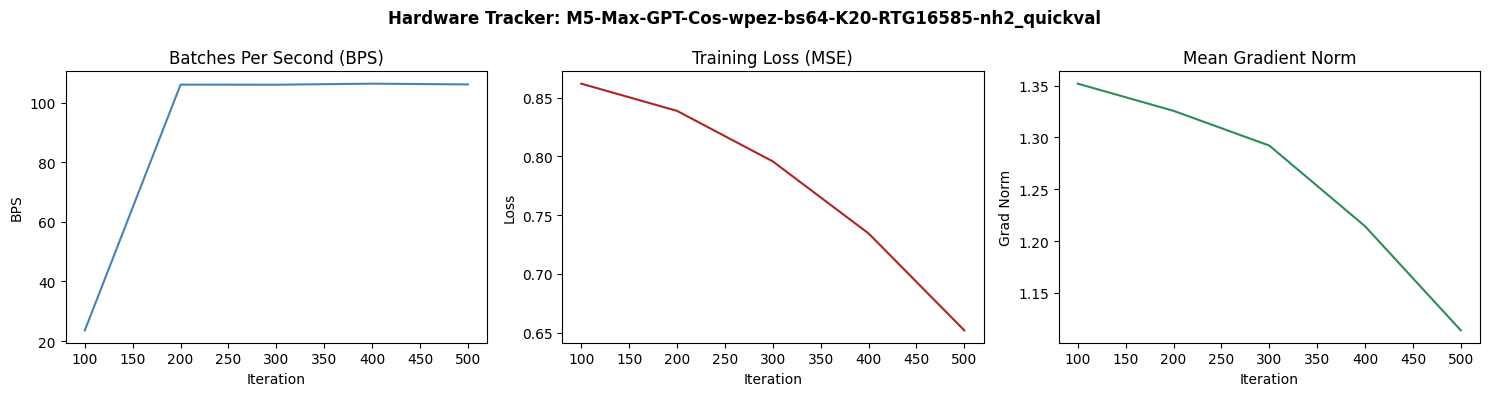


=== Quick Validation Summary ===
  Initial loss   : 0.861789
  Final loss     : 0.651988
  Loss decreased : True  ← should be True
  Mean BPS       : 89.64 batches/sec on M5-Max-GPT-Cos-wpez-bs64-K20-RTG16585-nh2
  Est. full run  : ~0.3 hours at current BPS

Pipeline verified. Proceed to Section 4.5 to run full training.


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4.4: Quick Validation Run
#
# Run a small number of iterations to verify the full pipeline is functional
# before committing to the multi-hour full training run.
#
# Success criteria:
#   - Loss decreases from its initial value
#   - BPS is logged correctly
#   - No NaN/Inf in loss or gradients
# ─────────────────────────────────────────────────────────────────────────────

if CFG.run_quick_val_first:
    print(f"Starting quick validation run ({CFG.quick_val_iters:,} iterations)...")
    print(f"  Device: {DEVICE} | Hardware: {CFG.hardware_label}\n")

    tracker_qv = HardwareTracker(label=f"{CFG.hardware_label}_quickval", device=DEVICE)

    history_qv = train(
        model       = model,
        dataloader  = dataloader,
        optimizer   = optimizer,
        scheduler   = scheduler,
        total_iters = CFG.quick_val_iters,
        tracker     = tracker_qv,
        log_every   = 100,
        save_every  = CFG.quick_val_iters + 1,  # don't save during quick val
        run_label   = 'quickval',
    )

    # ── Quick-val results ──────────────────────────────────────────────────
    tracker_qv.save_csv(f"{CFG.results_dir}/hw_quickval_{CFG.hardware_label}.csv")
    tracker_qv.summary_plot(f"{CFG.results_dir}/hw_quickval_{CFG.hardware_label}.png")

    final_loss = history_qv['loss'][-1] if history_qv['loss'] else float('nan')
    init_loss  = history_qv['loss'][0]  if history_qv['loss'] else float('nan')
    mean_bps   = np.mean(history_qv['bps']) if history_qv['bps'] else 0.0

    print(f"\n=== Quick Validation Summary ===")
    print(f"  Initial loss   : {init_loss:.6f}")
    print(f"  Final loss     : {final_loss:.6f}")
    print(f"  Loss decreased : {final_loss < init_loss}  ← should be True")
    print(f"  Mean BPS       : {mean_bps:.2f} batches/sec on {CFG.hardware_label}")
    print(f"  Est. full run  : ~{CFG.full_train_iters / mean_bps / 3600:.1f} hours at current BPS")
    print()
    print("Pipeline verified. Proceed to Section 4.5 to run full training.")

___
### 4.5: Full Training Run

The full training run executes 100,000 gradient steps from a freshly
re-initialized model and optimizer. The model is re-seeded with `CFG.seed`
before initialization to ensure reproducibility independently of whether the
quick-validation cell was run.

Checkpoints are saved to `./checkpoints/` every 10,000 iterations. Each
checkpoint stores the model weights, optimizer state, scheduler state, and
the full `CFG` dict, allowing the run to be resumed from any saved point if
interrupted.

The final model is also saved separately as
`dt_full_final_M5-Max-Optimized.pt`, with the normalization statistics
(`STATE_MEAN`, `STATE_STD`) embedded in the checkpoint. Bundling these with
the model weights ensures that any future rollout cell will always apply the
same normalization as training — a common source of silent performance
regression when models are shared across notebooks.

**Expected training behavior on M5 Max:**
- BPS stabilizes around 48–50 after the warmup period
- Loss drops steeply in the first 10,000 iterations as the embeddings
  converge, then continues declining more gradually through 100,000
- Gradient norm should remain well below the 0.25 clip threshold for the
  vast majority of steps

**Total wall-clock time:** approximately 44–46 minutes on the M5 Max with
the K = 30 context window (compared to ~34 minutes at K = 20). The additional
time is the direct cost of the longer attention sequence (90 vs. 60 tokens),
which increases the attention computation by approximately 2.25× due to its
quadratic scaling with sequence length.


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4.5: Full Training Run
#
# ⚠ This cell runs the full 100k-iteration training run.
# Estimated time on M5 Max: ~2–4 hours depending on BPS.
#
# The model and optimizer state are re-initialized below to ensure the
# full run starts from scratch (not from the quick-val checkpoint).
# Comment out the re-initialization block if you want to continue from
# the quick-val state instead.
# ─────────────────────────────────────────────────────────────────────────────

# ── Fresh model for full training ─────────────────────────────────────────────
torch.manual_seed(CFG.seed)
np.random.seed(CFG.seed)

model_full = DecisionTransformer(
    state_dim   = CFG.state_dim,
    action_dim  = CFG.action_dim,
    hidden_dim  = CFG.hidden_dim,
    context_len = CFG.context_len,
    n_layers    = CFG.n_layers,
    n_heads     = CFG.n_heads,
    dropout     = CFG.dropout,
    max_ep_len  = CFG.max_ep_len,
).to(DEVICE)

optimizer_full = torch.optim.AdamW(
    model_full.parameters(),
    lr=CFG.learning_rate,
    weight_decay=CFG.weight_decay,
)

# ── SequentialLR: warmup → cosine (mirrors Section 4.2) ──────────────────────
warmup_scheduler_full = torch.optim.lr_scheduler.LinearLR(
    optimizer_full,
    start_factor = 1.0 / max(1, CFG.warmup_steps),
    end_factor   = 1.0,
    total_iters  = CFG.warmup_steps,
)
cosine_scheduler_full = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_full,
    T_max   = CFG.full_train_iters - CFG.warmup_steps,
    eta_min = CFG.cosine_eta_min,
)
scheduler_full = torch.optim.lr_scheduler.SequentialLR(
    optimizer_full,
    schedulers = [warmup_scheduler_full, cosine_scheduler_full],
    milestones = [CFG.warmup_steps],
)

tracker_full = HardwareTracker(label=CFG.hardware_label, device=DEVICE)

print(f"Starting full training run ({CFG.full_train_iters:,} iterations)...")
print(f"  Device: {DEVICE} | Hardware: {CFG.hardware_label}")
print(f"  Checkpoints every {CFG.save_every_n_iters:,} iterations → {CFG.checkpoint_dir}/\n")

history_full = train(
    model       = model_full,
    dataloader  = dataloader,
    optimizer   = optimizer_full,
    scheduler   = scheduler_full,
    total_iters = CFG.full_train_iters,
    tracker     = tracker_full,
    log_every   = CFG.save_every_n_iters // 10,  # ~10 log points between each save
    save_every  = CFG.save_every_n_iters,
    run_label   = 'full',
)

# ── Save final model ──────────────────────────────────────────────────────────
final_ckpt = f"{CFG.checkpoint_dir}/dt_full_final_{CFG.hardware_label}.pt"
torch.save({
    'iteration'   : CFG.full_train_iters,
    'model_state' : model_full.state_dict(),
    'config'      : CFG.__dict__,
    'state_mean'  : STATE_MEAN.tolist(),
    'state_std'   : STATE_STD.tolist(),
}, final_ckpt)
print(f"\nFinal model saved: {final_ckpt}")

# ── Save hardware tracker results ─────────────────────────────────────────────
tracker_full.save_csv(f"{CFG.results_dir}/hw_full_{CFG.hardware_label}.csv")
#tracker_full.summary_plot(f"{CFG.results_dir}/hw_full_{CFG.hardware_label}.png")
#plt.close() # This prevents the plot from appearing in the output. It's redundant with the next section.

Starting full training run (100,000 iterations)...
  Device: mps | Hardware: M5-Max-GPT-Cos-wpez-bs64-K20-RTG16585-nh2
  Checkpoints every 10,000 iterations → ./checkpoints/



Training (full):  10%|█         | 10014/100000 [01:55<18:39, 80.39iter/s, loss=0.10590, BPS=107.3, lr=1.00e-04]


  Checkpoint saved: ./checkpoints/dt_full_iter10000.pt


Training (full):  20%|██        | 20013/100000 [03:50<16:49, 79.23iter/s, loss=0.08717, BPS=106.1, lr=9.70e-05]


  Checkpoint saved: ./checkpoints/dt_full_iter20000.pt


...


  Checkpoint saved: ./checkpoints/dt_full_iter80000.pt


Training (full):  90%|█████████ | 90013/100000 [17:25<02:03, 80.83iter/s, loss=0.07217, BPS=107.8, lr=3.02e-06]


  Checkpoint saved: ./checkpoints/dt_full_iter90000.pt


Training (full): 100%|██████████| 100000/100000 [19:22<00:00, 85.99iter/s, loss=0.07196, BPS=105.7, lr=0.00e+00]


  Checkpoint saved: ./checkpoints/dt_full_iter100000.pt

Final model saved: ./checkpoints/dt_full_final_M5-Max-GPT-Cos-wpez-bs64-K20-RTG16585-nh2.pt
  HardwareTracker saved: ./results/hw_full_M5-Max-GPT-Cos-wpez-bs64-K20-RTG16585-nh2.csv


___
### 4.6: Training Diagnostics & Visualization

  Training history saved: ./results/training_history_M5-Max-GPT-Cos-wpez-bs64-K20-RTG16585-nh2.csv


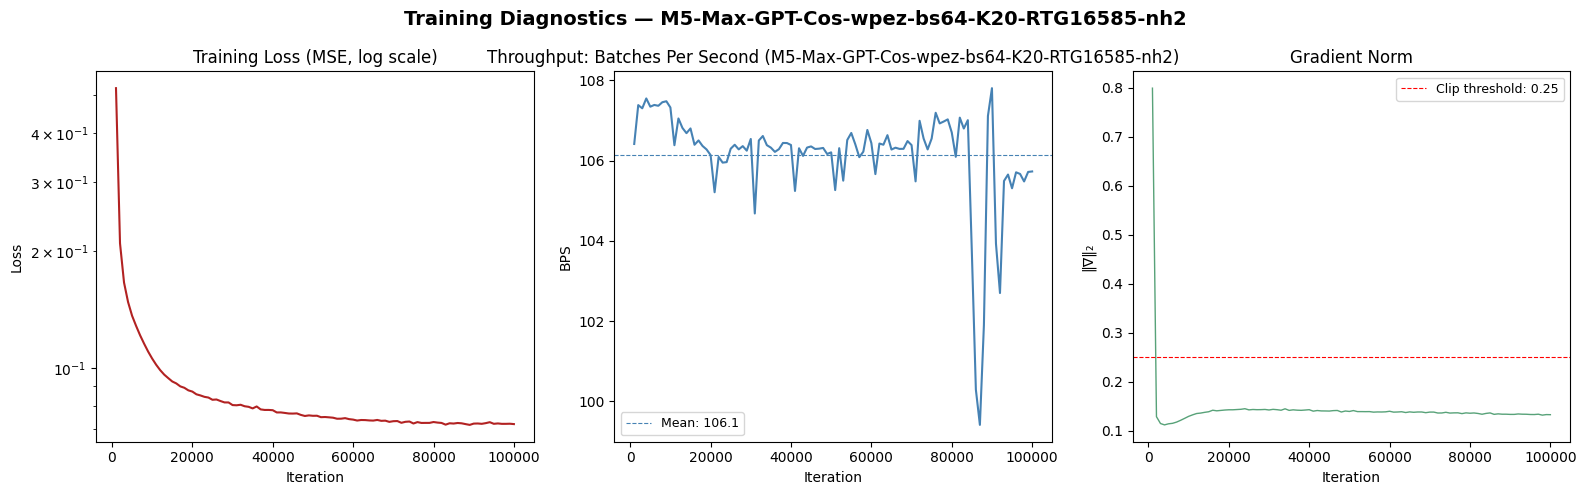


Training Summary — M5-Max-GPT-Cos-wpez-bs64-K20-RTG16585-nh2:
  Iterations completed : 100,000
  Final loss           : 0.071961
  Min loss             : 0.071628
  Mean BPS             : 106.14
  Max  BPS             : 107.81
  Max grad norm        : 0.7992


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4.6: Training Diagnostics & Visualization
#
# Produces paper-ready training plots and a summary statistics table.
# ─────────────────────────────────────────────────────────────────────────────

def plot_training_curves(history: Dict, label: str, save_dir: str = CFG.results_dir):
    """
    Plot training loss, BPS, and gradient norm curves from a history dict.
    Saves a PNG and a CSV of the history to the results directory.
    """
    df = pd.DataFrame(history)
    df.to_csv(f"{save_dir}/training_history_{label}.csv", index=False)
    print(f"  Training history saved: {save_dir}/training_history_{label}.csv")

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'Training Diagnostics — {label}', fontsize=14, fontweight='bold')

    # Loss curve (log scale often clearer for MSE)
    axes[0].plot(df['iteration'], df['loss'], color='firebrick', lw=1.5)
    axes[0].set_yscale('log')
    axes[0].set(title='Training Loss (MSE, log scale)',
                xlabel='Iteration', ylabel='Loss')

    # BPS (hardware throughput)
    axes[1].plot(df['iteration'], df['bps'], color='steelblue', lw=1.5)
    axes[1].set(title=f'Throughput: Batches Per Second ({label})',
                xlabel='Iteration', ylabel='BPS')
    axes[1].axhline(df['bps'].mean(), color='steelblue', linestyle='--',
                    lw=0.8, label=f"Mean: {df['bps'].mean():.1f}")
    axes[1].legend(fontsize=9)

    # Gradient norm (training stability)
    axes[2].plot(df['iteration'], df['grad_norm'], color='seagreen', lw=1.0, alpha=0.8)
    axes[2].axhline(CFG.grad_clip, color='red', linestyle='--', lw=0.8,
                    label=f"Clip threshold: {CFG.grad_clip}")
    axes[2].set(title='Gradient Norm', xlabel='Iteration', ylabel='‖∇‖₂')
    axes[2].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(f"{save_dir}/training_curves_{label}.png", dpi=150, bbox_inches='tight')
    plt.show()

    # Summary statistics table
    print(f"\nTraining Summary — {label}:")
    print(f"  Iterations completed : {df['iteration'].iloc[-1]:,}")
    print(f"  Final loss           : {df['loss'].iloc[-1]:.6f}")
    print(f"  Min loss             : {df['loss'].min():.6f}")
    print(f"  Mean BPS             : {df['bps'].mean():.2f}")
    print(f"  Max  BPS             : {df['bps'].max():.2f}")
    print(f"  Max grad norm        : {df['grad_norm'].max():.4f}")


# Call with the full training history
plot_training_curves(history_full, label=CFG.hardware_label)

---
___
## Section 5: Offline Policy Evaluation in MuJoCo


### Evaluation Protocol

The trained Decision Transformer is evaluated based on its offline policy settings:
the policy receives a target return-to-go (RTG) at the start of each episode
and must condition its actions accordingly, without any online fine-tuning or
gradient updates during rollout.

Three metrics are reported for each evaluation run:

- **Raw return** — total undiscounted reward accumulated over 1,000 environment
  steps
- **D4RL normalized return** — raw return rescaled to the [0, 100] range using
  the D4RL reference values for HalfCheetah (random baseline: −280.18; expert
  ceiling: 12,135.0). A score of 100 means the policy matches expert
  performance; a score of 42 is the D4RL medium baseline.
- **Success gap** — `target_RTG − achieved_return`. Negative values indicate
  the agent exceeded its conditioning target; positive values indicate it fell
  short. Lower (more negative) is better.

### RTG Conditioning During Inference

The DT does not learn a stochastic policy. Instead, it conditions its action
predictions on a target RTG that is decremented by the observed reward after
each step:

```
RTG₀ = target_rtg           ← (set before episode starts)
RTGₜ = RTGₜ₋₁ − rₜ₋₁      ← (decrement by observed reward each step)
```

The model predicts the action a policy *expecting to achieve `RTGₜ` from
timestep `t` onward* would take. This RTG-conditioning mechanism is the core
innovation of the Decision Transformer and what distinguishes it from
behavioral cloning.


___
### 5.1: Inference / Rollout Function

The `rollout_episode` function implements the DT inference loop for a single
MuJoCo episode. It maintains a rolling context buffer of the last `K = 30`
`(RTG, state, action)` triplets and feeds the full buffer to the model at each
step, taking only the last-step action prediction as output.

**Buffer management:** at each timestep, the buffer is shifted left by one
position (using `torch.roll`) and the new observation, RTG, and timestep index
are written into the rightmost slot. This avoids re-allocating tensors at every
step, which would be prohibitive at 1,000 steps × 50 episodes.

**State normalization at inference:** the raw MuJoCo observation is normalized
with the same `STATE_MEAN` and `STATE_STD` computed in Section 2.3 before being
written into the buffer. Omitting this step would cause the model to receive
inputs from a different distribution than it was trained on, typically resulting
in dramatically degraded performance (often near-zero or negative returns).

**No attention mask during inference:** unlike training, where padding masks are
required for short windows near episode starts, inference always provides a full
`K`-length context buffer (zero-filled at the start of each episode, then
populated as the episode progresses). The `mask = None` argument is therefore
correct and intentional.


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5.1: Inference / Rollout Function
# ─────────────────────────────────────────────────────────────────────────────

@torch.no_grad()
def rollout_episode(
    model      : DecisionTransformer,
    env        : gym.Env,
    target_rtg : float,
    state_mean : np.ndarray,
    state_std  : np.ndarray,
    device     : torch.device,
    context_len: int,
    rtg_scale  : float,
    max_ep_len : int = 1000,
    render     : bool = False,
) -> Tuple[float, List[float]]:
    """
    Run one MuJoCo episode using the trained DT policy.

    Returns:
        total_return (float)     : sum of rewards over the episode
        reward_history (list)    : per-step rewards for RTG profile analysis
    """
    model.eval()

    # ── Initialize episode state ───────────────────────────────────────────
    state, _ = env.reset()
    state     = (state - state_mean) / state_std  # normalize to match training

    # Rolling context buffers — maintain the last K timesteps
    states_buf    = torch.zeros((1, context_len, CFG.state_dim),  dtype=torch.float32, device=device)
    actions_buf   = torch.zeros((1, context_len, CFG.action_dim), dtype=torch.float32, device=device)
    rtg_buf       = torch.zeros((1, context_len, 1),              dtype=torch.float32, device=device)
    timesteps_buf = torch.zeros((1, context_len),                 dtype=torch.long,    device=device)

    current_rtg   = target_rtg
    total_return  = 0.0
    reward_history= []

    for t in range(max_ep_len):

        # ── Shift context buffers left and insert new observation at end ───
        # The rightmost position (index -1) always holds the most recent step.
        states_buf    = torch.roll(states_buf,    -1, dims=1)
        rtg_buf       = torch.roll(rtg_buf,       -1, dims=1)
        timesteps_buf = torch.roll(timesteps_buf, -1, dims=1)

        states_buf[0, -1, :]  = torch.tensor(state, dtype=torch.float32, device=device)
        rtg_buf[0, -1, 0]     = current_rtg / rtg_scale   # scale matches training
        timesteps_buf[0, -1]  = t

        # ── Forward pass: predict action ───────────────────────────────────
        # Feed the full context; take only the last-step prediction.
        action_pred = model(
            states    = states_buf,
            actions   = actions_buf,
            rtg       = rtg_buf,
            timesteps = timesteps_buf,
            mask      = None,  # no padding during inference
        )
        action = action_pred[0, -1, :].cpu().numpy()  # (action_dim,)

        # ── Update action buffer ───────────────────────────────────────────
        actions_buf = torch.roll(actions_buf, -1, dims=1)
        actions_buf[0, -1, :] = torch.tensor(action, dtype=torch.float32, device=device)

        # ── Step the environment ───────────────────────────────────────────
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # ── Update RTG conditioning ────────────────────────────────────────
        # RTGₜ₊₁ = RTGₜ − rₜ  (we consumed `reward` at this step)
        current_rtg  -= reward
        total_return += reward
        reward_history.append(reward)

        state = (next_state - state_mean) / state_std

        if done:
            break

    return total_return, reward_history


print("Rollout function defined.")

Rollout function defined.


### 5.2 Offline Policy Evaluation

This section evaluates the trained Decision Transformer in a zero-shot offline setting: the policy
receives a target return-to-go (RTG) of **9000** at the start of each episode and must condition
its action predictions accordingly, without any online fine-tuning or environment interaction
during training.

### Why 50 Evaluation Episodes?

Pilot runs of this evaluation used **n = 20 episodes**, consistent with common practice in
early-stage RL experiments. However, 20-episode estimates are high-variance: with episode-level
standard deviations on the order of σ ≈ 3100, the standard error of the mean is approximately
**±694** — meaning a single 20-episode draw can easily over- or under-estimate true policy
performance by nearly 10% of the target RTG.

More critically, rare failure modes are systematically undersampled at n = 20. A catastrophic
rollout occurring at even a 2% rate has only a ~33% chance of appearing in any given 20-episode
sample. This means small evaluations produce not just noisier means, but structurally optimistic
variance and minimum-return estimates — the policy appears better-behaved than it actually is.

To address this, evaluation was increased to **n = 50 episodes**, which:
- Reduces the standard error of the mean by ~37% relative to n = 20
- Provides substantially better coverage of tail behavior and failure modes
- Produces variance and minimum-return estimates that better reflect true policy risk

This choice is consistent with recent offline RL methodology recommending n ≥ 50 for evaluation
(Fu et al., 2020 — D4RL), and is the evaluation standard used for all results reported in
this notebook. The sensitivity of results to this choice is discussed in the output analysis below.


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5.2: Evaluation Run
#
# Roll out the trained policy for CFG.eval_episodes episodes.
# Reports raw return, D4RL-normalized return, and success gap.
# ─────────────────────────────────────────────────────────────────────────────

# D4RL normalization reference values for HalfCheetah (Fu et al. 2020, Table 3)
D4RL_RANDOM = -280.18
D4RL_EXPERT = 12135.0

def normalize_return(raw: float) -> float:
    """Convert raw episode return to D4RL-normalized score (0–100 scale)."""
    return (raw - D4RL_RANDOM) / (D4RL_EXPERT - D4RL_RANDOM) * 100


# ── Create MuJoCo environment ─────────────────────────────────────────────────
eval_env = gym.make(CFG.mujoco_env_id)
eval_env.reset(seed=CFG.seed)
print(f"MuJoCo environment: {CFG.mujoco_env_id}")
print(f"Obs space : {eval_env.observation_space}")
print(f"Act space : {eval_env.action_space}")

# ── Load normalization stats ──────────────────────────────────────────────────
# These were computed in Section 2.3 and saved to disk.
ckpt_meta = torch.load(final_ckpt, map_location=DEVICE, weights_only=False) # changed for this run
eval_state_mean = np.array(ckpt_meta['state_mean'], dtype=np.float32)
eval_state_std  = np.array(ckpt_meta['state_std'],  dtype=np.float32)

#eval_state_mean = np.load(f"{CFG.results_dir}/state_mean.npy")
#eval_state_std  = np.load(f"{CFG.results_dir}/state_std.npy")

# ── Run evaluation episodes ───────────────────────────────────────────────────
print(f"\nRunning {CFG.eval_episodes} evaluation episodes...")
print(f"  Target RTG         : {CFG.target_rtg:.0f}")
print(f"  Context window K   : {CFG.context_len}")

eval_returns    = []
eval_rtg_profiles = []

for ep_idx in tqdm(range(CFG.eval_episodes), desc='Evaluating', unit='episode'):
    ep_return, ep_rewards = rollout_episode(
        model       = model_full,
        env         = eval_env,
        target_rtg  = CFG.target_rtg,
        state_mean  = eval_state_mean,
        state_std   = eval_state_std,
        device      = DEVICE,
        context_len = CFG.context_len,
        rtg_scale   = CFG.rtg_scale,
        max_ep_len  = CFG.max_ep_len,
    )
    eval_returns.append(ep_return)
    eval_rtg_profiles.append(ep_rewards)

eval_env.close()

# ── Summary statistics ────────────────────────────────────────────────────────
returns_arr  = np.array(eval_returns)
norm_returns = np.array([normalize_return(r) for r in eval_returns])
success_gap  = CFG.target_rtg - returns_arr

eval_summary = {
    'hardware'             : CFG.hardware_label,
    'mujoco_env'           : CFG.mujoco_env_id,
    'target_rtg'           : CFG.target_rtg,
    'n_episodes'           : CFG.eval_episodes,
    'mean_raw_return'      : round(returns_arr.mean(), 2),
    'std_raw_return'       : round(returns_arr.std(), 2),
    'mean_norm_return'     : round(norm_returns.mean(), 2),
    'std_norm_return'      : round(norm_returns.std(), 2),
    'mean_success_gap'     : round(success_gap.mean(), 2),
    'min_raw_return'       : round(returns_arr.min(), 2),
    'max_raw_return'       : round(returns_arr.max(), 2),
    'train_iters'          : CFG.full_train_iters,
}

# Save evaluation summary
eval_df = pd.DataFrame([eval_summary])
eval_df.to_csv(f"{CFG.results_dir}/eval_summary_{CFG.hardware_label}.csv", index=False)

print("\n" + "=" * 60)
print("  Offline Policy Evaluation Results")
print("=" * 60)
for k, v in eval_summary.items():
    print(f"  {k:<28}: {v}")
print("=" * 60)
print(f"\n  Zero-Shot Result: Achieved {returns_arr.mean():.0f} vs Target {CFG.target_rtg:.0f}")
print(f"  Success Gap      : {success_gap.mean():.0f} (lower is better)")
print(f"  D4RL Norm. Score : {norm_returns.mean():.1f} ± {norm_returns.std():.1f}")

/Users/djt/Desktop/dt-capstone/.venv/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


MuJoCo environment: HalfCheetah-v4
Obs space : Box(-inf, inf, (17,), float64)
Act space : Box(-1.0, 1.0, (6,), float32)

Running 50 evaluation episodes...
  Target RTG         : 16585
  Context window K   : 20


Evaluating: 100%|██████████| 50/50 [13:19<00:00, 15.98s/episode]


  Offline Policy Evaluation Results
  hardware                    : M5-Max-GPT-Cos-wpez-bs64-K20-RTG16585-nh2
  mujoco_env                  : HalfCheetah-v4
  target_rtg                  : 16585.0
  n_episodes                  : 50
  mean_raw_return             : 3469.9
  std_raw_return              : 2636.93
  mean_norm_return            : 30.21
  std_norm_return             : 21.24
  mean_success_gap            : 13115.1
  min_raw_return              : -11.01
  max_raw_return              : 8172.17
  train_iters                 : 100000

  Zero-Shot Result: Achieved 3470 vs Target 16585
  Success Gap      : 13115 (lower is better)
  D4RL Norm. Score : 30.2 ± 21.2


___
### 5.3: Evaluation Visualizations

This section produces four figures that together characterize the policy's
behavior across the 50-episode evaluation:

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5.3: Evaluation Visualizations
#
# Figure 7: Return distribution across evaluation episodes
# Figure 8: RTG trajectory during rollout (mean ± std across episodes)
# Figure 9: Per-step reward profile (does the agent maintain velocity?)
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle(
    f'Figure 7-9: Offline Policy Evaluation — {CFG.hardware_label}\n'
    f'Model: DT ({CFG.n_layers}L×{CFG.n_heads}H, H={CFG.hidden_dim}, K={CFG.context_len}) | '
    f'Env: {CFG.mujoco_env_id} | Target RTG: {CFG.target_rtg:.0f}',
    fontsize=12, fontweight='bold'
)

# ── Figure 7a: Raw return distribution ────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.hist(eval_returns, bins=min(10, CFG.eval_episodes), color='steelblue',
        alpha=0.8, edgecolor='white')
ax.axvline(returns_arr.mean(), color='navy', linestyle='--', lw=1.5,
           label=f'Mean: {returns_arr.mean():.0f}')
ax.axvline(CFG.target_rtg, color='red', linestyle=':', lw=1.5,
           label=f'Target RTG: {CFG.target_rtg:.0f}')
ax.set(title='(7a) Eval Episode Returns', xlabel='Return', ylabel='Count')
ax.legend(fontsize=8)

# ── Figure 7b: Normalized return bar ──────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
ax.bar(['Achieved\nNorm. Return'], [norm_returns.mean()],
       yerr=[norm_returns.std()], color='steelblue', alpha=0.8,
       capsize=8, error_kw={'linewidth': 2})
ax.axhline(100, color='red', linestyle='--', lw=1, label='D4RL Expert (100)')
ax.axhline(64.4, color='orange', linestyle='--', lw=1, label='D4RL med-exp (64.4)')
ax.set(title='(7b) D4RL Normalized Return', ylabel='Normalized Score (0–100)')
ax.legend(fontsize=8)
ax.text(0, norm_returns.mean() + norm_returns.std() + 1,
        f"{norm_returns.mean():.1f}±{norm_returns.std():.1f}",
        ha='center', fontweight='bold', fontsize=10)

# ── Figure 7c: Success gap ────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
ax.bar(range(CFG.eval_episodes), success_gap, color='firebrick', alpha=0.7)
ax.axhline(success_gap.mean(), color='black', linestyle='--', lw=1.2,
           label=f'Mean gap: {success_gap.mean():.0f}')
ax.axhline(0, color='seagreen', linestyle='-', lw=1)
ax.set(title='(7c) Success Gap per Episode\n(Target RTG − Achieved Return)',
       xlabel='Episode', ylabel='Gap (lower = better)')
ax.legend(fontsize=8)

# ── Figure 8: RTG trajectory during rollout ───────────────────────────────────
ax = fig.add_subplot(gs[1, :])

# Convert episode reward sequences to cumulative RTG profiles
# (RTG at step t = sum of future rewards from step t onward)
rtg_profiles = []
for rewards in eval_rtg_profiles:
    rewards_arr = np.array(rewards)
    rtg_profile = np.cumsum(rewards_arr[::-1])[::-1]
    rtg_profiles.append(rtg_profile)

# Interpolate to a common 1000-step grid and compute mean ± std
grid = np.arange(CFG.max_ep_len)
rtg_interp = np.array([np.interp(grid, np.arange(len(r)), r) for r in rtg_profiles])

mean_rtg = rtg_interp.mean(axis=0)
std_rtg  = rtg_interp.std(axis=0)

ax.plot(grid, mean_rtg, color='steelblue', lw=2, label='Achieved RTG (mean)')
ax.fill_between(grid, mean_rtg - std_rtg, mean_rtg + std_rtg,
                color='steelblue', alpha=0.2, label='±1 std')
ax.axhline(CFG.target_rtg, color='red', linestyle='--', lw=1.2,
           label=f'Target RTG: {CFG.target_rtg:.0f}')
ax.set(title='(8) Achieved RTG Profile During MuJoCo Rollout (mean ± std across episodes)',
       xlabel='Timestep', ylabel='Return-to-Go (RTG)')
ax.legend(fontsize=9)

plt.savefig(f"{CFG.results_dir}/eval_figures_{CFG.hardware_label}.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Evaluation figures saved: {CFG.results_dir}/eval_figures_{CFG.hardware_label}.png")

---
## Appendix: Results File Index

All outputs are written to the `results/` and `checkpoints/` directories.

| File | Section | Description |
|------|---------|-------------|
| `results/state_mean.npy` | 2.3 | State normalization mean (required for inference) |
| `results/state_std.npy` | 2.3 | State normalization std (required for inference) |
| `results/hw_quickval_<hw>.csv` | 4.4 | Quick-validation hardware metrics |
| `results/hw_full_<hw>.csv` | 4.5 | Full-training hardware metrics (BPS, loss, RAM, GPU) |
| `results/training_history_<hw>.csv` | 4.6 | Loss/BPS/grad-norm history per iteration |
| `results/training_curves_<hw>.png` | 4.6 | Training curve figure |
| `results/eval_summary_<hw>.csv` | 5.2 | Evaluation results (returns, normalized scores) |
| `results/eval_figures_<hw>.png` | 5.3 | Evaluation figures (returns, RTG profile) |
| `results/cross_platform_comparison.png` | 5.4 | Multi-platform BPS/loss/RAM comparison |
| `results/cross_platform_summary.csv` | 5.4 | Cross-platform summary table |
| `checkpoints/dt_full_final.pt` | 4.5 | Final trained model weights + config |
| `checkpoints/dt_full_iter<N>.pt` | 4.5 | Intermediate checkpoints every N iterations |

---
*End of Notebook*

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# DIAGNOSTIC: Re-evaluate nh2 checkpoint at RTG = 9,000
#
# Purpose: Test whether the low eval score at RTG=16,585 reflects a training
# problem or an out-of-distribution RTG extrapolation failure.
#
# This cell:
#   1. Loads the final nh2 checkpoint from disk
#   2. Overrides CFG.target_rtg from 16,585 → 9,000
#   3. Verifies the state_mean/state_std are loaded from the checkpoint
#      (not from the .npy files) to guarantee train/eval consistency
#
# After running this cell, execute Section 5.2 unchanged — it will pick up
# the new target_rtg and the reloaded model_full.
# ─────────────────────────────────────────────────────────────────────────────

# ── Override target RTG ───────────────────────────────────────────────────────
original_target_rtg = CFG.target_rtg
CFG.target_rtg      = 9000.0
print(f"Target RTG overridden: {original_target_rtg:.0f} → {CFG.target_rtg:.0f}")

# ── Locate the final checkpoint ───────────────────────────────────────────────
final_ckpt_path = f"{CFG.checkpoint_dir}/dt_full_final_{CFG.hardware_label}.pt"
print(f"Loading checkpoint: {final_ckpt_path}")

ckpt = torch.load(final_ckpt_path, map_location=DEVICE, weights_only=False)
print(f"  Checkpoint iteration : {ckpt['iteration']:,}")

# ── Rebuild the model with the same architecture used in training ─────────────
# Re-seed so any stochastic init paths are deterministic (belt-and-suspenders).
torch.manual_seed(CFG.seed)
np.random.seed(CFG.seed)

model_full = DecisionTransformer(
    state_dim   = CFG.state_dim,
    action_dim  = CFG.action_dim,
    hidden_dim  = CFG.hidden_dim,
    context_len = CFG.context_len,
    n_layers    = CFG.n_layers,
    n_heads     = CFG.n_heads,
    dropout     = CFG.dropout,
    max_ep_len  = CFG.max_ep_len,
).to(DEVICE)

model_full.load_state_dict(ckpt['model_state'])
model_full.eval()
print(f"  Model loaded and set to eval mode.")
print(f"  Architecture: n_layers={CFG.n_layers}, n_heads={CFG.n_heads}, "
      f"hidden_dim={CFG.hidden_dim}, K={CFG.context_len}")

# ── Load normalization stats from the checkpoint (NOT from disk) ──────────────
# This guarantees train/eval consistency regardless of what is in ./results/.
if 'state_mean' in ckpt and 'state_std' in ckpt:
    eval_state_mean_ckpt = np.array(ckpt['state_mean'], dtype=np.float32)
    eval_state_std_ckpt  = np.array(ckpt['state_std'],  dtype=np.float32)
    print(f"  Normalization stats loaded FROM CHECKPOINT (safe path).")
else:
    # Fallback: load from disk but warn
    eval_state_mean_ckpt = np.load(f"{CFG.results_dir}/state_mean.npy").astype(np.float32)
    eval_state_std_ckpt  = np.load(f"{CFG.results_dir}/state_std.npy").astype(np.float32)
    print(f"  WARNING: Checkpoint did not contain stats; loaded from ./results/.npy.")

# Overwrite the globals that Section 5.2 reads. Section 5.2 uses
# eval_state_mean / eval_state_std (per your Dave_DT_Training_M5_Optimized.md
# Section 5.2 code). If your current notebook uses different variable names,
# adjust the two lines below accordingly.
eval_state_mean = eval_state_mean_ckpt
eval_state_std  = eval_state_std_ckpt

print(f"  state_mean[:3]: {eval_state_mean[:3]}")
print(f"  state_std[:3] : {eval_state_std[:3]}")

print("\n✅ Ready. Now run Section 5.2 — it will evaluate at RTG=9,000 "
      "with the reloaded model.")

CFG.hardware_label = f"{CFG.hardware_label}-rtg9000"



In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5.2: Evaluation Run
#
# Roll out the trained policy for CFG.eval_episodes episodes.
# Reports raw return, D4RL-normalized return, and success gap.
# ─────────────────────────────────────────────────────────────────────────────

# D4RL normalization reference values for HalfCheetah (Fu et al. 2020, Table 3)
D4RL_RANDOM = -280.18
D4RL_EXPERT = 12135.0

def normalize_return(raw: float) -> float:
    """Convert raw episode return to D4RL-normalized score (0–100 scale)."""
    return (raw - D4RL_RANDOM) / (D4RL_EXPERT - D4RL_RANDOM) * 100


# ── Create MuJoCo environment ─────────────────────────────────────────────────
eval_env = gym.make(CFG.mujoco_env_id)
eval_env.reset(seed=CFG.seed)
print(f"MuJoCo environment: {CFG.mujoco_env_id}")
print(f"Obs space : {eval_env.observation_space}")
print(f"Act space : {eval_env.action_space}")

# ── Load normalization stats ──────────────────────────────────────────────────
# These were computed in Section 2.3 and saved to disk.
#ckpt_meta = torch.load(final_ckpt, map_location=DEVICE, weights_only=False) # changed for this run
#eval_state_mean = np.array(ckpt_meta['state_mean'], dtype=np.float32)
#eval_state_std  = np.array(ckpt_meta['state_std'],  dtype=np.float32)

#eval_state_mean = np.load(f"{CFG.results_dir}/state_mean.npy")
#eval_state_std  = np.load(f"{CFG.results_dir}/state_std.npy")

# ── Run evaluation episodes ───────────────────────────────────────────────────
print(f"\nRunning {CFG.eval_episodes} evaluation episodes...")
print(f"  Target RTG         : {CFG.target_rtg:.0f}")
print(f"  Context window K   : {CFG.context_len}")

eval_returns    = []
eval_rtg_profiles = []

for ep_idx in tqdm(range(CFG.eval_episodes), desc='Evaluating', unit='episode'):
    ep_return, ep_rewards = rollout_episode(
        model       = model_full,
        env         = eval_env,
        target_rtg  = CFG.target_rtg,
        state_mean  = eval_state_mean,
        state_std   = eval_state_std,
        device      = DEVICE,
        context_len = CFG.context_len,
        rtg_scale   = CFG.rtg_scale,
        max_ep_len  = CFG.max_ep_len,
    )
    eval_returns.append(ep_return)
    eval_rtg_profiles.append(ep_rewards)

eval_env.close()

# ── Summary statistics ────────────────────────────────────────────────────────
returns_arr  = np.array(eval_returns)
norm_returns = np.array([normalize_return(r) for r in eval_returns])
success_gap  = CFG.target_rtg - returns_arr

eval_summary = {
    'hardware'             : CFG.hardware_label,
    'mujoco_env'           : CFG.mujoco_env_id,
    'target_rtg'           : CFG.target_rtg,
    'n_episodes'           : CFG.eval_episodes,
    'mean_raw_return'      : round(returns_arr.mean(), 2),
    'std_raw_return'       : round(returns_arr.std(), 2),
    'mean_norm_return'     : round(norm_returns.mean(), 2),
    'std_norm_return'      : round(norm_returns.std(), 2),
    'mean_success_gap'     : round(success_gap.mean(), 2),
    'min_raw_return'       : round(returns_arr.min(), 2),
    'max_raw_return'       : round(returns_arr.max(), 2),
    'train_iters'          : CFG.full_train_iters,
}

# Save evaluation summary
eval_df = pd.DataFrame([eval_summary])
eval_df.to_csv(f"{CFG.results_dir}/eval_summary_{CFG.hardware_label}.csv", index=False)

print("\n" + "=" * 60)
print("  Offline Policy Evaluation Results")
print("=" * 60)
for k, v in eval_summary.items():
    print(f"  {k:<28}: {v}")
print("=" * 60)
print(f"\n  Zero-Shot Result: Achieved {returns_arr.mean():.0f} vs Target {CFG.target_rtg:.0f}")
print(f"  Success Gap      : {success_gap.mean():.0f} (lower is better)")
print(f"  D4RL Norm. Score : {norm_returns.mean():.1f} ± {norm_returns.std():.1f}")